# Problema Extra: Evaluación automática de ecualización de histograma

La ecualización de histograma permite mejorar el contraste de una imagen redistribuyendo los
niveles de intensidad de los píxeles.

No todas las imágenes requieren este proceso, ya que una imagen con buen contraste ya posee
una distribución adecuada de intensidades.

Para automatizar esta decisión se propone un indicador entre 0 y 1 basado en el contraste
de la imagen:

- Valores cercanos a 0 indican que la imagen tiene buena distribución de intensidades y no
  necesita ecualización.
- Valores cercanos a 1 indican que la imagen presenta poco contraste y requiere
  ecualización.

Si el indicador obtenido es mayor a 0.5, se aplicará automáticamente la ecualización del
histograma utilizando OpenCV.

## Método de evaluación

Para determinar la necesidad de ecualización se utilizará la desviación estándar de los
niveles de intensidad de la imagen.

Una imagen con bajo contraste tendrá poca variación entre sus píxeles, por lo que la
desviación estándar será baja.

Por otro lado, una imagen con mayor contraste tendrá una distribución más amplia de
intensidades.

El valor obtenido será normalizado entre 0 y 1 para utilizarlo como indicador de necesidad
de ecualización.

## Función de evaluación

La función analiza la desviación estándar de los niveles de gris.

Una imagen con poco contraste concentra sus valores en un rango pequeño, por lo que presenta
una desviación estándar baja.

Una imagen con mayor contraste tendrá una distribución más amplia y una desviación estándar
mayor.

In [5]:
import cv2
import numpy as np


def analizar_ecualizacion(imagen_gris):
    
    
    # Calcular contraste mediante desviación estándar
    contraste = np.std(imagen_gris)
    
    
    # Convertir contraste a escala 0-1
    indice = 1 - (contraste / 64)
    
    
    # Limitar rango
    indice = np.clip(indice,0,1)
    
    
    print("Índice de necesidad de ecualización:", round(float(indice),3))
    
    
    if indice > 0.5:
        print("Resultado: La imagen requiere ecualización")
        ecualizada = cv2.equalizeHist(imagen_gris)
        
    else:
        print("Resultado: La imagen no requiere ecualización")
        ecualizada = imagen_gris
        
        
    return ecualizada, indice

## Visualización de histogramas

Para comprobar el efecto de la ecualización se muestran los histogramas antes y después.

El histograma representa la cantidad de píxeles presentes para cada nivel de intensidad
entre 0 y 255.

In [6]:
import matplotlib.pyplot as plt


def mostrar_histogramas(original, resultado):
    
    
    plt.figure(figsize=(12,4))
    
    
    plt.subplot(1,2,1)
    plt.hist(original.ravel(),256,[0,256])
    plt.title("Histograma original")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    
    
    plt.subplot(1,2,2)
    plt.hist(resultado.ravel(),256,[0,256])
    plt.title("Histograma después")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    
    
    plt.show()

Prueba 1

In [7]:
import os


ruta_carpeta = r"C:\Users\luisi\Documents\Maestria BI\Analisis de datos\Text Mining & Image Recognition\Lab2\Imagenes lab"


archivo = [x for x in os.listdir(ruta_carpeta) if x.startswith("1")][0]


ruta = os.path.join(ruta_carpeta,archivo)


imagen = cv2.imread(ruta)


gris = cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)


resultado, indice = analizar_ecualizacion(gris)

Índice de necesidad de ecualización: 0.362
Resultado: La imagen no requiere ecualización


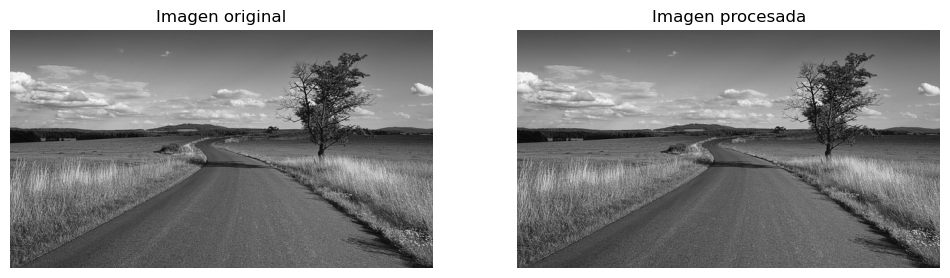

C:\Users\luisi\AppData\Local\Temp\ipykernel_47668\1924309281.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(original.ravel(),256,[0,256])
C:\Users\luisi\AppData\Local\Temp\ipykernel_47668\1924309281.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(resultado.ravel(),256,[0,256])


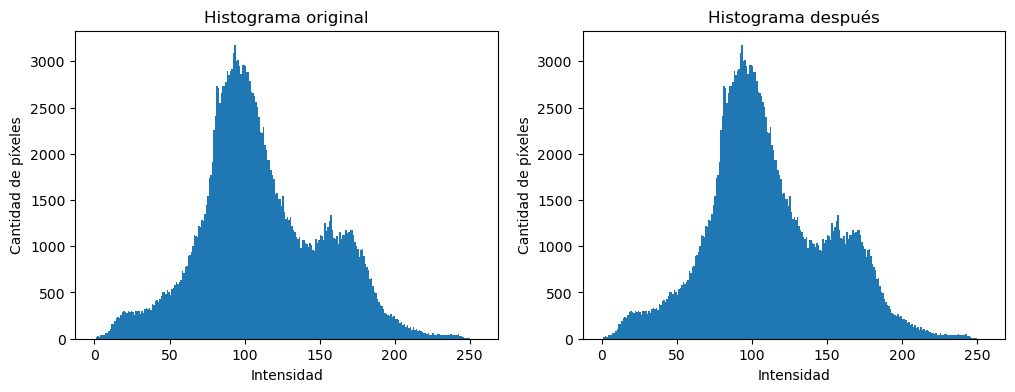

In [8]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.imshow(gris,cmap="gray")
plt.title("Imagen original")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(resultado,cmap="gray")
plt.title("Imagen procesada")
plt.axis("off")


plt.show()


mostrar_histogramas(gris,resultado)

# Evaluación de las 5 imágenes del laboratorio

Finalmente se probará la función sobre todas las imágenes disponibles para comparar el
índice obtenido y determinar cuáles requieren ecualización.

In [9]:
import pandas as pd


resultados = []


for archivo in sorted(os.listdir(ruta_carpeta)):
    
    if archivo.startswith(("1","2","3","4","5")):
        
        
        ruta = os.path.join(ruta_carpeta,archivo)
        
        
        imagen = cv2.imread(ruta)
        
        
        gris = cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
        
        
        _, indice = analizar_ecualizacion(gris)
        
        
        resultados.append([
            archivo,
            round(float(indice),3),
            "Sí" if indice > 0.5 else "No"
        ])
        

tabla = pd.DataFrame(
    resultados,
    columns=[
        "Imagen",
        "Índice Ecualización",
        "¿Requiere?"
    ]
)


tabla

Índice de necesidad de ecualización: 0.362
Resultado: La imagen no requiere ecualización
Índice de necesidad de ecualización: 0.173
Resultado: La imagen no requiere ecualización
Índice de necesidad de ecualización: 0.0
Resultado: La imagen no requiere ecualización
Índice de necesidad de ecualización: 0.428
Resultado: La imagen no requiere ecualización
Índice de necesidad de ecualización: 0.0
Resultado: La imagen no requiere ecualización


,Imagen,Índice Ecualización,¿Requiere?
0,1.jpg,0.362,No
1,2.jpg,0.173,No
2,3.jpg,0.000,No
3,4.jpg,0.428,No
4,5.jpg,0.000,No


## Prueba con una imagen de bajo contraste

Para verificar el comportamiento de la función se generará una versión con bajo contraste
reduciendo la diferencia entre los niveles de intensidad de la imagen original.

Esta imagen simulada concentra sus valores en un rango pequeño, por lo que debería requerir
ecualización.

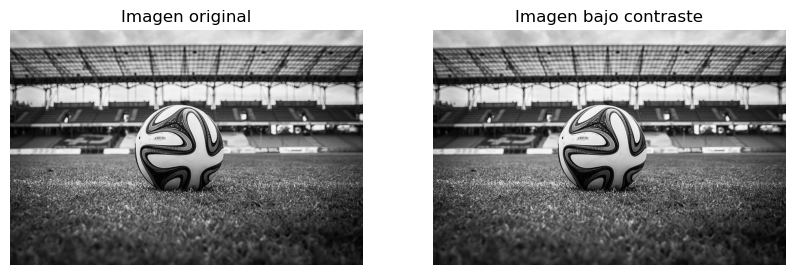

In [10]:
# Crear imagen con bajo contraste

bajo_contraste = cv2.convertScaleAbs(
    gris,
    alpha=0.3,
    beta=100
)


plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.imshow(gris,cmap="gray")
plt.title("Imagen original")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(bajo_contraste,cmap="gray")
plt.title("Imagen bajo contraste")
plt.axis("off")


plt.show()

In [11]:
resultado_bajo, indice_bajo = analizar_ecualizacion(bajo_contraste)

Índice de necesidad de ecualización: 0.688
Resultado: La imagen requiere ecualización


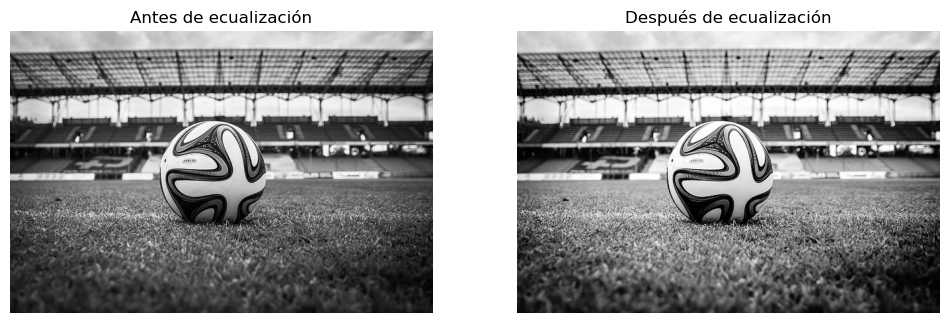

C:\Users\luisi\AppData\Local\Temp\ipykernel_47668\1924309281.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(original.ravel(),256,[0,256])
C:\Users\luisi\AppData\Local\Temp\ipykernel_47668\1924309281.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(resultado.ravel(),256,[0,256])


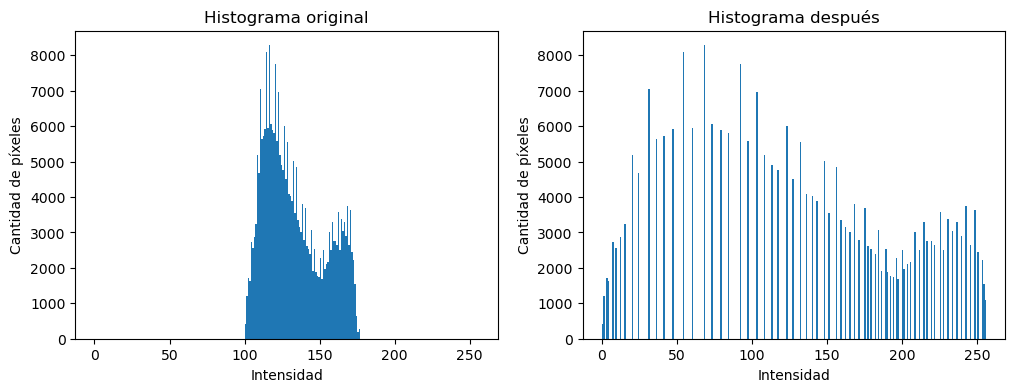

In [12]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.imshow(bajo_contraste,cmap="gray")
plt.title("Antes de ecualización")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(resultado_bajo,cmap="gray")
plt.title("Después de ecualización")
plt.axis("off")


plt.show()


mostrar_histogramas(bajo_contraste,resultado_bajo)